In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
import xarray as xr

#Import custom package for working with Beaufort Gyre data
from datatools import io
import datatools.DOT.operations as sops
import datatools.plots.maps as mapper
from pyproj import Transformer
from scipy.interpolate import LinearNDInterpolator


In [3]:
sat_ds_new = io.readers.readDOT("/Users/ben/Desktop/3D-TEA-BAG/data/Full_DOT_data_Arco_2025_09.nc")
sat_ds_old = io.readers.readDOT("/Users/ben/Desktop/3D-TEA-BAG/data/CPOM_DOT.nc", engine = 'scipy')

new_data = sat_ds_new.sel(time=4049)
old_data = sat_ds_old.sel(date=201102)

In [4]:
#Get the distance from the north pole of (0,0) in (x,y) coordinates
lon_0 = 0
lat_ts = 68.65
# lat_ts = 90


proj_str = (f"+proj=stere +lat_0=90 +lat_ts={lat_ts} +lon_0={lon_0} "
            f"+k=1 +x_0=0 +y_0=0 +a=6378137.0 +b=6356752.3142 +units=km +no_defs")

transformer = Transformer.from_crs("EPSG:4326", "EPSG:3413", always_xy=True)
lat_0 = new_data.sel(x=0,y=0)['lats']
lon_0 = new_data.sel(x=0,y=0)['lons']

x0, y0 = transformer.transform(lon_0, lat_0)  # lon, lat of your (0,0) corner
print(x0, y0)


0.0 -4729530.640074975


In [5]:

grid_spacing = 20e3 #20km square grid
grid_shape = new_data['lats'].shape
x_cords = np.arange(grid_shape[0])*grid_spacing+x0
y_cords = np.arange(grid_shape[1])*grid_spacing+y0
fake_data = np.atleast_2d(np.arange(grid_shape[0])).T @ np.atleast_2d(np.arange(grid_shape[1]))
sops.bilinear_interp_npstere(fake_data, x_cords, y_cords,61.607574,-166.0973, lat_ts=lat_ts, lon_0=0)

(array([-750.66609626]), array([3032.68810459]))


nan

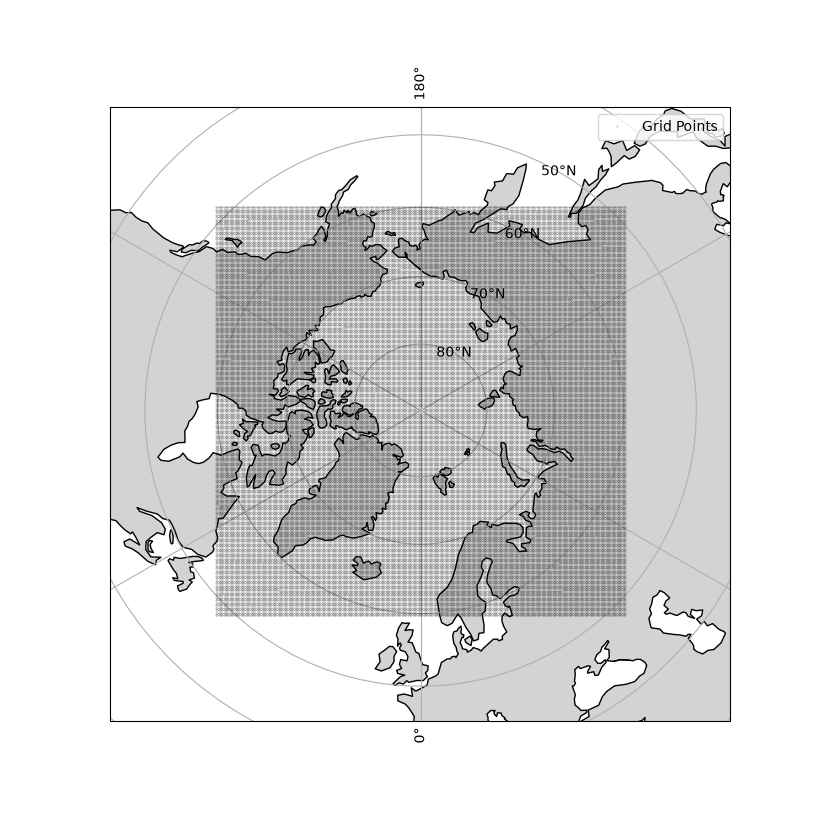

In [6]:
location_figure = plt.figure(figsize=(8,8))
projection=ccrs.NorthPolarStereo(central_longitude=0)
extent = [-165, 165, 45, 90]

ax = mapper.setup_map(figure=location_figure,
                 projection=projection,
                 extent=extent)

ax = mapper.plot_locations(ax = ax, lat = new_data['lats'][::2], lon = new_data['lons'][::2], label = 'Grid Points', markersize=0.125)

plt.legend()
ax.set_title("CryoSat-2 DOT Grid Points")
plt.show()

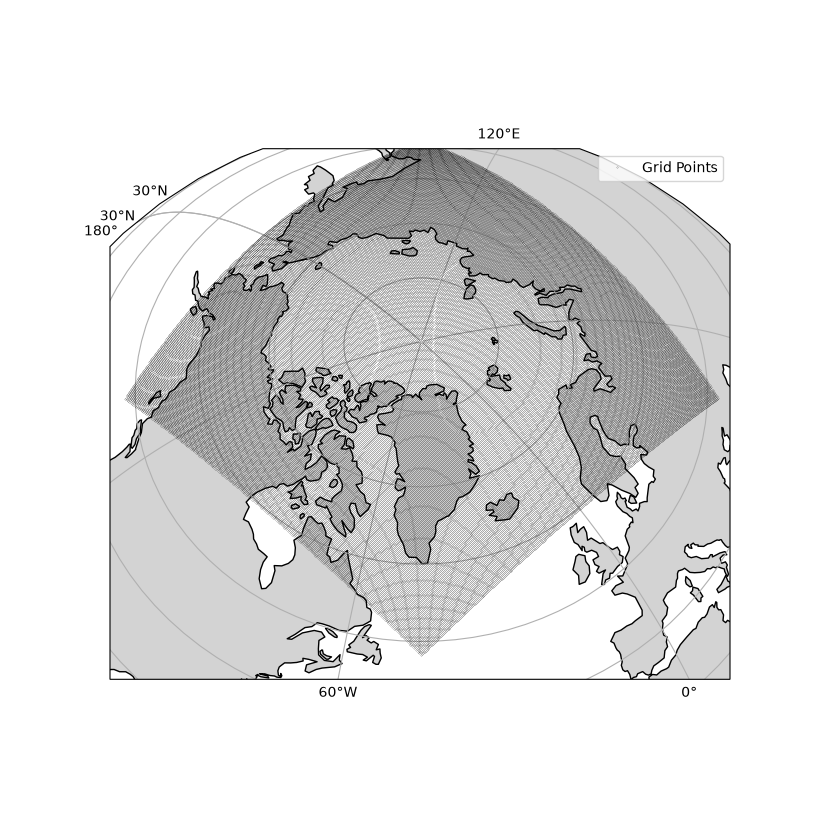

In [7]:
location_figure = plt.figure(figsize=(8,8))
projection=ccrs.Orthographic(central_longitude=-45, central_latitude=60)
extent = [-165, 165, 45, 90]

ax = mapper.setup_map(figure=location_figure,
                 projection=projection,
                 extent=extent)

ax = mapper.plot_locations(ax = ax, lat = new_data['lats'][::2], lon = new_data['lons'][::2], label = 'Grid Points', markersize=0.125)

plt.legend()
ax.set_title("CryoSat-2 DOT Grid Points")
plt.show()

In [8]:
##USE THIS INTERPOLATION METHOD
flat_lats = new_data['lats'].values.ravel()
flat_lons = new_data['lons'].values.ravel()
points = np.vstack((flat_lats, flat_lons)).T

interp = LinearNDInterpolator(points, fake_data.ravel())





In [9]:
#Plot geostrophic current velocity

#Calculate the U and V components of geostrophic current with respect to lat/lon in the new dataset
sat_ds_new['U'] = sat_ds_new['Geo_surf_current_y']*sat_ds_new['ang_c']+sat_ds_new['Geo_surf_current_x']*sat_ds_new['ang_s']
sat_ds_new['V'] = sat_ds_new['Geo_surf_current_x']*sat_ds_new['ang_c']-sat_ds_new['Geo_surf_current_y']*sat_ds_new['ang_s']

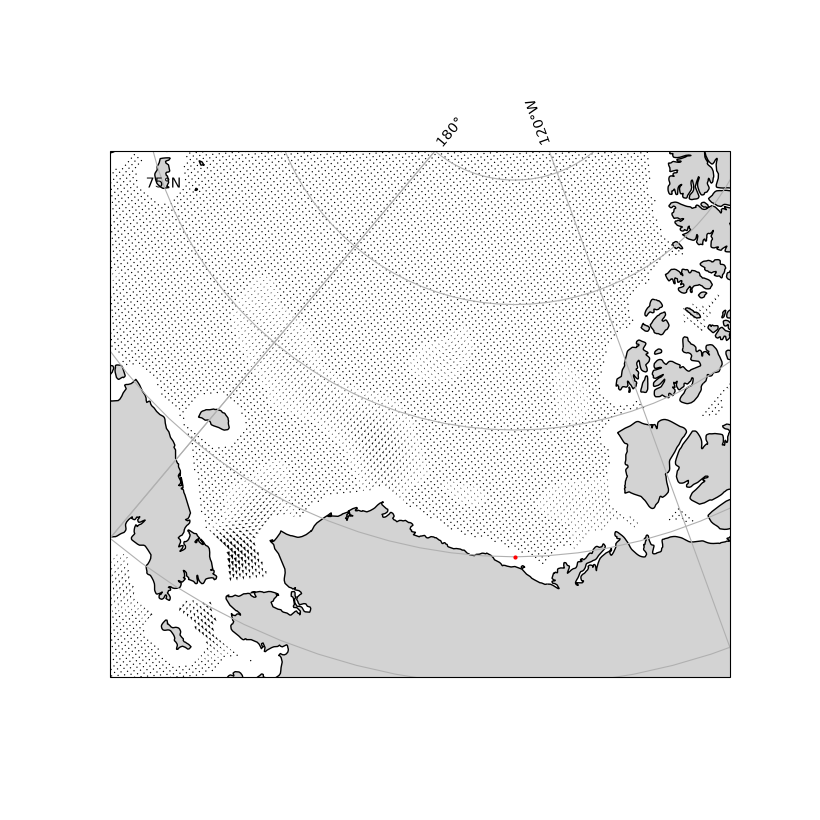

In [19]:
#Setup a figure in the Beaufort Gyre Area (plus 10˚ on each side)
location_figure = plt.figure(figsize=(8,8))
projection=ccrs.NorthPolarStereo(central_longitude=-140)
extent = [-180, -120, 65, 85]

ax = mapper.setup_map(figure=location_figure,
                 projection=projection,
                 extent=extent)
working_da = sat_ds_new.sel(time=4169)

ax.quiver(x = working_da['lons'].values.ravel(), y = working_da['lats'].values.ravel(), u = working_da['U'].values.ravel(), v = working_da['V'].values.ravel(), transform=ccrs.PlateCarree())
mapper.plot_locations(ax, 70,-140,color = 'r')

plt.show()